# Analisis Tren Global dan Pola Konsumsi Industri Video Game (1980 - 2016)

### **Latar Belakang**

Industri video game telah bertransformasi dari pasar hobi yang kecil di era 80-an menjadi salah satu industri hiburan terbesar di dunia. Namun, dengan ribuan judul yang dirilis setiap tahun, dinamika pasar menjadi sangat kompleks. Dataset ini mencatat lebih dari 16.000 judul game, yang mencakup informasi penjualan di berbagai wilayah, genre, dan platform.

### **Masalah & Pertanyaan Utama**

Dalam analisis ini, saya ingin menggali lebih dalam mengenai beberapa aspek kunci:

1. **Tren Waktu:** Bagaimana perkembangan industri game dari tahun ke tahun? Kapan masa kejayaannya dan apa yang memicu perubahan tersebut?
2. **Dinamika Pasar:** Apakah pertumbuhan industri dirasakan secara merata oleh semua pengembang, atau hanya didominasi oleh segelintir game populer (*blockbuster*)?
3. **Distribusi Geografis:** Bagaimana kontribusi wilayah seperti Amerika Utara, Eropa, dan Jepang terhadap total penjualan global seiring berjalannya waktu?

### **Tujuan Analisis**

Tujuan dari proyek ini adalah untuk memberikan gambaran komprehensif mengenai sejarah penjualan video game fisik dan mengidentifikasi pola perilaku pasar yang dapat digunakan sebagai referensi untuk memahami tren industri di masa depan.

### **Tentang Dataset**

Dataset yang digunakan berasal dari **vgsales.csv** (sumber: Kaggle). Dataset ini mencakup data penjualan video game yang terjual lebih dari 100.000 kopi, memiliki  16rb leih rows dan 11 kolom  dengan rincian sebagai berikut:

* **Rank:** Peringkat penjualan keseluruhan.
* **Name:** Nama game.
* **Platform:** Konsol tempat game dirilis.
* **Year:** Tahun rilis.
* **Genre:** Kategori game.
* **Publisher:** Perusahaan penerbit game.
* **Sales (NA, EU, JP, Other, Global):** Angka penjualan dalam juta unit berdasarkan wilayah.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
## Load Dataset

data = pd.read_csv('vgsales.csv')
data


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


---DATA CLEANING---

In [7]:
## Data understanding dan mencari jumlah missing values
data.info()
data.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

berdasarkan informasi di atas disimpulkan bahwa
1. terdapat inccorect type data pada kolom year, seharusnya integer
2. terdapat missing value pada kolom year sebanyak  271 dan publisher sebanyak 58

untuk melakukan analisis tren, dibutuhkan data yang benar benar bersih dan rill
maka dari itu penghapusdan missing value adalah solusinya


In [ ]:
## handle missing value
data_tren = data.dropna(subset=['Year'])
data_tren = data_tren.dropna(subset=['Publisher'])

In [39]:
## handle incorrect data type
data_tren['Year']= data_tren['Year'].astype(int)

In [77]:
print(f"Informasi data set setelah dilakukannya handle missing values dan incorrect data")
data_tren.info()

Informasi data set setelah dilakukannya handle missing values dan incorrect data
<class 'pandas.core.frame.DataFrame'>
Index: 16291 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16291 non-null  int64  
 1   Name          16291 non-null  object 
 2   Platform      16291 non-null  object 
 3   Year          16291 non-null  int64  
 4   Genre         16291 non-null  object 
 5   Publisher     16291 non-null  object 
 6   NA_Sales      16291 non-null  float64
 7   EU_Sales      16291 non-null  float64
 8   JP_Sales      16291 non-null  float64
 9   Other_Sales   16291 non-null  float64
 10  Global_Sales  16291 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 1.5+ MB


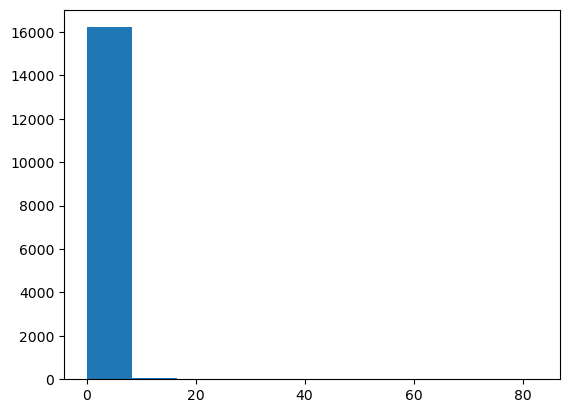

In [ ]:
## cek outlier
plt.hist(data_tren['Global_Sales'])

plt.show()

In [81]:
## cek outlier menggunakan IQR
Q1 = data_tren['Global_Sales'].quantile(0.25)
Q3 = data_tren['Global_Sales'].quantile(0.75)

IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

outlier = data_tren[
    (data_tren['Global_Sales'] < batas_bawah) |
    (data_tren['Global_Sales'] > batas_atas)
]


outlier[['Name', 'Global_Sales']]

,Name,Global_Sales
0,Wii Sports,82.74
1,Super Mario Bros.,40.24
2,Mario Kart Wii,35.82
3,Wii Sports Resort,33.00
4,Pokemon Red/Pokemon Blue,31.37
...,...,...
1842,Need for Speed: ProStreet,1.11
1843,Pikmin 3,1.11
1844,Legend of Mana,1.11
1845,Lumines: Puzzle Fusion,1.11


walaupun terdapat 1826 outlier pada kolom Global_Sales, saya memutuskan untuk tidak menghapusnya karena mereka adalah game blockbuster yang penting untuk analisis tren.


---VISUALISASI DAN ANALISIS---

Dalam menyusun tren tahunan, saya menggunakan kombinasi nilai Total dan Median untuk menyeimbangkan pengaruh outlier (game super hits) terhadap gambaran pasar secara umum. Selain itu, analisis dibatasi hingga tahun 2016 untuk menghindari kesalahan interpretasi akibat data yang tidak lengkap pada tahun-tahun terbaru (data cutoff).

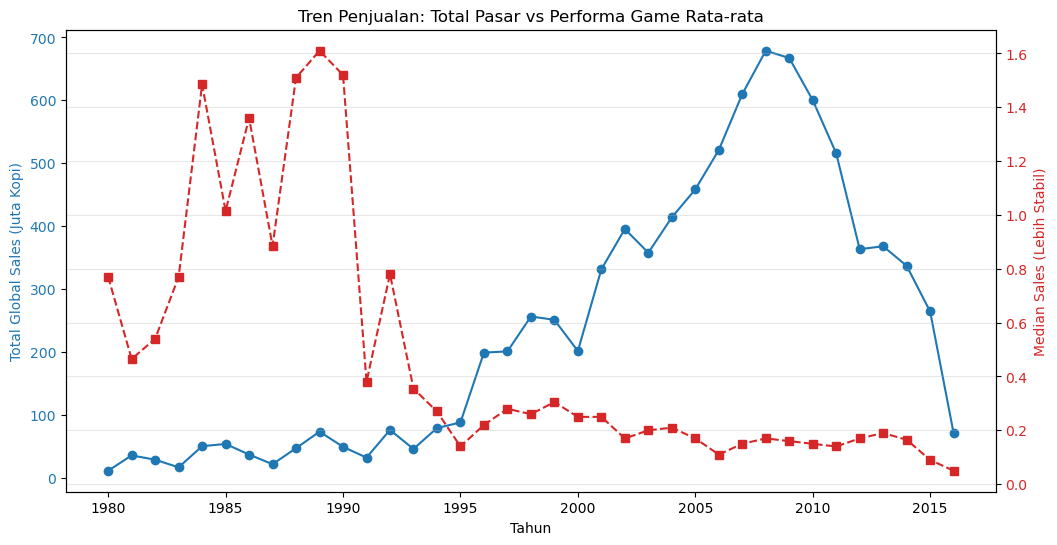

In [71]:

# 1. Mengelompokkan data berdasarkan tahun
# Menghitung Sum untuk total pasar, dan Median agar tidak tertipu outlier
tren_tahunan = data_tren.groupby('Year')['Global_Sales'].agg(['sum', 'median']).reset_index()

# 2. Filter tahun (hanya sampai 2016 karena data setelah tahun 2016 tidak relevan atau kurang lengkap)
tren_tahunan = tren_tahunan[tren_tahunan['Year'] <= 2016]

# 3. Visualisasi untuk membandingkan keduanya
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Total Sales (Sumbu Y Kiri)
ax1.set_xlabel('Tahun')
ax1.set_ylabel('Total Global Sales (Juta Kopi)', color='tab:blue')
ax1.plot(tren_tahunan['Year'], tren_tahunan['sum'], color='tab:blue', marker='o', label='Total Penjualan')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Membuat sumbu Y kedua untuk Median (Sumbu Y Kanan)
ax2 = ax1.twinx() 
ax2.set_ylabel('Median Sales (Lebih Stabil)', color='tab:red')
ax2.plot(tren_tahunan['Year'], tren_tahunan['median'], color='tab:red', linestyle='--', marker='s', label='Median (Game Rata-rata)')
ax2.tick_params(axis='y', labelcolor='tab:red')

plt.title('Tren Penjualan: Total Pasar vs Performa Game Rata-rata')
plt.grid(True, alpha=0.3)
plt.show()

1. Era Awal Industri (1980 - 1990): Pasar Kecil, tapi Game Individual Sangat Kuat
Fakta pada Grafik: Garis biru mendekati 0, sedangkan garis merah melonjak sangat tinggi (bahkan mencapai puncaknya mendekati 1.6 juta kopi per game di sekitar tahun 1989).

Pada era ini, jumlah game yang dirilis masih sedikit (suplai rendah), namun konsol seperti NES (Nintendo Entertainment System) sedang booming. Karena pilihan game sedikit, kompetisi sangat rendah. Akibatnya, hampir setiap game yang rilis sukses besar secara rata-rata (median tinggi), meskipun total industri secara keseluruhan belum sebesar era modern.

2. Ledakan Industri dan Titik Balik (1995 - 2008):
Fakta pada Grafik: Mulai tahun 1995 (era PlayStation 1), garis biru meroket tajam hingga puncaknya di tahun 2008 (hampir menyentuh 700 juta kopi). Di sisi lain, garis merah justru terjun bebas ke bawah angka 0.4.

Ini adalah fenomena menarik. Industri video game tumbuh raksasa secara kapital (garis biru naik), tetapi kesuksesan game secara rata-rata justru menurun drastis (garis merah turun). Hal ini terjadi karena pasar mulai dibanjiri oleh ribuan game baru setiap tahunnya (oversaturation). Kompetisi menjadi sangat brutal, dan pasar mulai didominasi oleh game-game raksasa saja (blockbuster/AAA).

3. Fenomena Setelah Tahun 2008: Kejenuhan Pasar dan Penurunan Data fisik
Fakta pada Grafik: Setelah tahun 2008, kedua garis mengalami penurunan yang sangat drastis hingga tahun 2016.

Kejenuhan Konsol: Generasi konsol saat itu (PS3/Xbox 360) mulai mencapai akhir siklus hidupnya menjelang transisi ke generasi berikutnya.

Faktor Data Digital (Paling Krusial): Dataset publik video game (seperti dari VGChartz yang biasa digunakan di dataset ini) umumnya hanya mencatat penjualan fisik. Setelah tahun 2008, industri beralih besar-besaran ke arah digital (Steam, PlayStation Network, Xbox Live) serta menjamurnya mobile games (Android/iOS) yang tidak tercatat di data penjualan retail tradisional ini.

Untuk memberikan perspektif yang lebih mendalam pada analisis tren, saya menggunakan Stacked Area Chart. Grafik ini memungkinkan kita untuk melihat akumulasi total penjualan global sekaligus kontribusi spesifik dari setiap wilayah (Amerika Utara, Eropa, Jepang, dan wilayah lainnya) dalam satu waktu. Sumbu X menunjukkan tahun rilis, sedangkan ketebalan warna pada sumbu Y menunjukkan volume penjualan masing-masing wilayah."

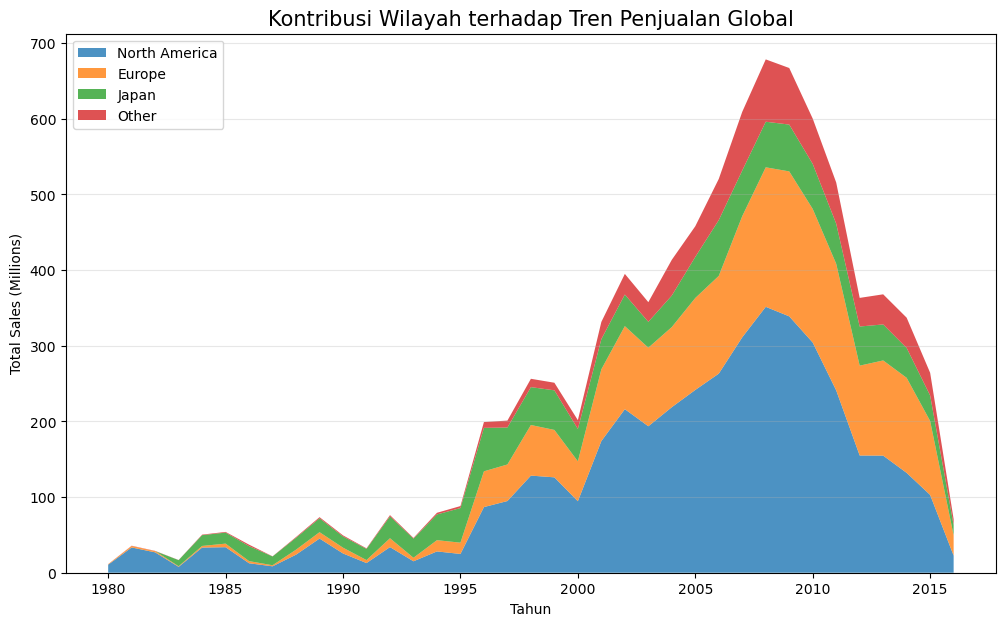

In [ ]:
''' Untuk memberikan perspektif yang lebih mendalam pada analisis tren, saya menggunakan Stacked Area Chart. 
 Grafik ini memungkinkan kita untuk melihat akumulasi total penjualan global sekaligus kontribusi spesifik dari setiap wilayah 
 (Amerika Utara, Eropa, Jepang, dan wilayah lainnya) dalam satu waktu. Sumbu X menunjukkan tahun rilis, sedangkan ketebalan warna pada sumbu 
 Y menunjukkan volume penjualan masing-masing wilayah.'''

# 1. Agregasi penjualan per wilayah berdasarkan tahun
tren_wilayah = data_tren.groupby('Year')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum().reset_index()
tren_wilayah = tren_wilayah[tren_wilayah['Year'] <= 2016]

# 2. Membuat Stacked Area Chart
plt.figure(figsize=(12, 7))
plt.stackplot(tren_wilayah['Year'], 
              tren_wilayah['NA_Sales'], 
              tren_wilayah['EU_Sales'], 
              tren_wilayah['JP_Sales'], 
              tren_wilayah['Other_Sales'], 
              labels=['North America', 'Europe', 'Japan', 'Other'],
              alpha=0.8)

plt.title('Kontribusi Wilayah terhadap Tren Penjualan Global', fontsize=15)
plt.xlabel('Tahun')
plt.ylabel('Total Sales (Millions)')
plt.legend(loc='upper left')
plt.grid(axis='y', alpha=0.3)
plt.show()

"Secara keseluruhan, industri mencapai puncak volume penjualan pada periode 2007-2009. Grafik ini membuktikan bahwa ledakan pasar di era tersebut didorong oleh pertumbuhan serentak di ketiga pasar utama (NA, EU, dan JP). Meskipun terjadi penurunan data setelah 2010 (akibat transisi ke digital), struktur pasar tetap menunjukkan bahwa Amerika Utara dan Eropa memegang kendali atas lebih dari 70% total penjualan fisik secara global."